# Task 2: Develop a Tell-the-Time Network

In [91]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from statistics import mean
from module import time_to_float


# Load the small dataset to start training
x_75 = np.load("A1_data_75/images.npy")
y_75 = np.load("A1_data_75/labels.npy")

# Normalise inputs, as in task 1
x_75 = x_75.astype('float32') / 255.0

# Split into training and test set and shuffle and since the datasets are ordered, it is recommended in the assignment spec to shuffle
x_75_train, x_75_test, y_75_train, y_75_test = train_test_split(x_75, y_75, test_size = 0.10, random_state = 2029197, shuffle = True)

# Split again into training-validation sets
x_75_train, x_75_validation, y_75_train, y_75_validation = train_test_split(x_75_train, y_75_train, test_size = 0.10, random_state = 202197)

tf.random.set_seed(202197)


## Subtask: Classification Model

### Data preparation

In [92]:
# Given grayscale images it has to be added to the information i.e. shape from (n,75,75) to (n,75,75,1)
x_75_train_cat = np.expand_dims(x_75_train, axis=-1)
x_75_validation_cat = np.expand_dims(x_75_validation, axis=-1)
x_75_test_cat = np.expand_dims(x_75_test, axis=-1)

In [93]:
# Function to bin time labels into x minute intervals
def split_into_bins(label, tot_minutes=30):
    """
    Groups time into inverals of total minutes (tot_minutes)
    30 minutes -> 24 groups
    15 minutes -> 48 groups
    10 minutes -> 72 groups
    5 minutes -> 144 groups
    1 minute -> 720 groups
    """
    arr = np.empty(label.shape[0], dtype=object)
    for i in range(label.shape[0]):
        hours = label[i][0]
        minutes = label[i][1]
        minute_bins=  minutes//tot_minutes
        new_label = f'{hours}:{minute_bins*tot_minutes:02d}'
        arr[i] = new_label
    return arr

In [94]:
arrays = [y_75_train, y_75_validation, y_75_test]

# Make categorical tests for 30 (24 classes), 15 (48 classes) and 10 (72 classes) minutes intervals
y_75_categorical_24 = [split_into_bins(arr,30) for arr in arrays]
y_75_categorical_48 = [split_into_bins(arr,15) for arr in arrays]
y_75_categorical_72 = [split_into_bins(arr,10) for arr in arrays]

In [95]:
# Turn the string-based categories into factors in order to let our model know that this is a categorical variable
factor24 = LabelEncoder()
factor24.fit(np.concatenate(y_75_categorical_24))
y_75_train_categorical_24 = factor24.transform(y_75_categorical_24[0])
y_75_validation_categorical_24 = factor24.transform(y_75_categorical_24[1])
y_75_test_categorical_24 = factor24.transform(y_75_categorical_24[2])

factor48 = LabelEncoder()
factor48.fit(np.concatenate(y_75_categorical_48))
y_75_train_categorical_48 = factor48.transform(y_75_categorical_48[0])
y_75_validation_categorical_48 = factor48.transform(y_75_categorical_48[1])
y_75_test_categorical_48 = factor48.transform(y_75_categorical_48[2])


factor72 = LabelEncoder()
factor72.fit(np.concatenate(y_75_categorical_72))
y_75_train_categorical_72 = factor72.fit_transform(y_75_categorical_72[0])
y_75_validation_categorical_72 = factor72.transform(y_75_categorical_72[1])
y_75_test_categorical_72 = factor72.transform(y_75_categorical_72[2])

### Circular Mean Absolute (time) Error 

In [96]:
def evaluate_circular_mae_cat(model, X, y_true_RAW, label_encoder):
    raw_pred = model.predict(X)
    pred_classes = np.argmax(raw_pred, axis=1)
    y_pred_str = label_encoder.inverse_transform(pred_classes)

    # split string
    y_pred_split = np.array([x.split(':') for x in y_pred_str], dtype=int)

    # make int
    y_pred_time=np.array([[int(i) for i in x] for x in y_pred_split])

    # convert to float using helper func
    y_pred_float = time_to_float(y_pred_time)
    y_true_float = time_to_float(y_true_RAW)

    y_pred_norm = y_pred_float/12
    y_true_norm = y_true_float/12
    

    # # Circular MAE
    abs_diff = np.abs(y_true_norm - y_pred_norm)
    circular_diff = np.minimum(abs_diff, 1 - abs_diff)
    circular_mae_value = np.mean(circular_diff)
    output= [circular_mae_value,round(circular_mae_value*720,3)]

    return output

### Model list and model history initializer 

In [97]:
history_dict = {}
mae_results =[]


### Model Building (30 minutes intervals <-> 24 classes)

First model gives only random guesses, sometimes does find a spot. 

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.0399 - loss: 3.1790 - val_accuracy: 0.0451 - val_loss: 3.1793
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0433 - loss: 3.1782 - val_accuracy: 0.0358 - val_loss: 3.1787
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0416 - loss: 3.1753 - val_accuracy: 0.0556 - val_loss: 3.1587
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0988 - loss: 2.9171 - val_accuracy: 0.1728 - val_loss: 2.5773
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2078 - loss: 2.4003 - val_accuracy: 0.2685 - val_loss: 2.1796
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2906 - loss: 2.0706 - val_accuracy: 0.3272 - val_loss: 1.9014
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3678 - loss: 1.7982 - val_accuracy: 0.3963 - val_loss: 1.6414
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4466 - loss: 1.5610 - val_accuracy: 0.4765 - v

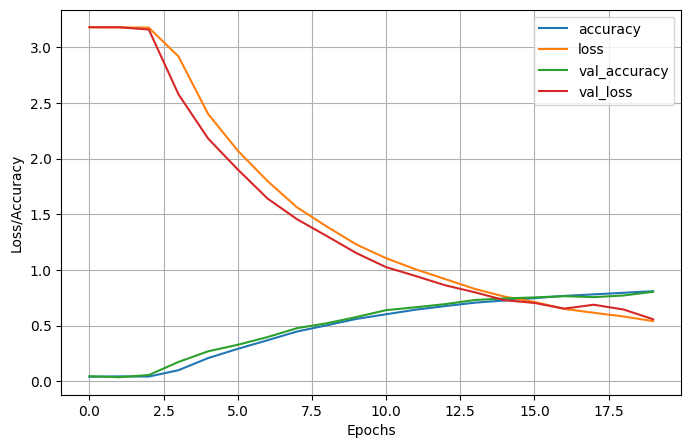

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [98]:
# Model building
class_24_model = keras.models.Sequential([
    #Specification of input shape
    keras.layers.Input(shape=(75,75,1)),
    # 3 convolutional layers to sequentially learn edges and what not
    keras.layers.Conv2D(16, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    # dropout to bring test accuray on par with train accuracy
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    # One dense layer to  bring condense all information and make global connections
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(24, activation='softmax')
])

class_24_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

history = class_24_model.fit(x_75_train_cat, y_75_train_categorical_24,
        batch_size=150,
        epochs=20,
        verbose=1,
        validation_data=(x_75_validation_cat, y_75_validation_categorical_24))
score = class_24_model.evaluate(x_75_validation_cat, y_75_validation_categorical_24, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_model, x_75_validation_cat, y_75_validation, factor24))

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()

history_dict['base_24']=history
mae_results.append(["base_24", evaluate_circular_mae_cat(class_24_model, x_75_validation_cat,  y_75_validation, factor24)])


#### Addition of batch normalization

Implementation of batch normalization seems to stabilize the model, the model is definitely learning but the validation accuracy is fluctuating. 

The best explanation for this phenomena could be grounded into the validation set not being representative of the dataset. Another model is tried with a higher amount of filters in the final layer. This seemed to make it worse. The first model is kept and the learning rate is lowered. 

Epoch 1/40


/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.0444 - loss: 3.1922 - val_accuracy: 0.0358 - val_loss: 3.1780
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0545 - loss: 3.1595 - val_accuracy: 0.0420 - val_loss: 3.1831
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0642 - loss: 3.0902 - val_accuracy: 0.0358 - val_loss: 3.1780
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0715 - loss: 3.0246 - val_accuracy: 0.0358 - val_loss: 3.2033
Epoch 5/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0823 - loss: 2.9282 - val_accuracy: 0.0383 - val_loss: 3.3853
Epoch 6/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0975 - loss: 2.8107 - val_accuracy: 0.0790 - val_loss: 2.9507
Epoch 7/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1235 - loss: 2.6762 - val_accuracy: 0.1031 - val_loss: 2.8090
Epoch 8/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1330 - loss: 2.6099 - val_accuracy: 0.0951 - val_loss: 2

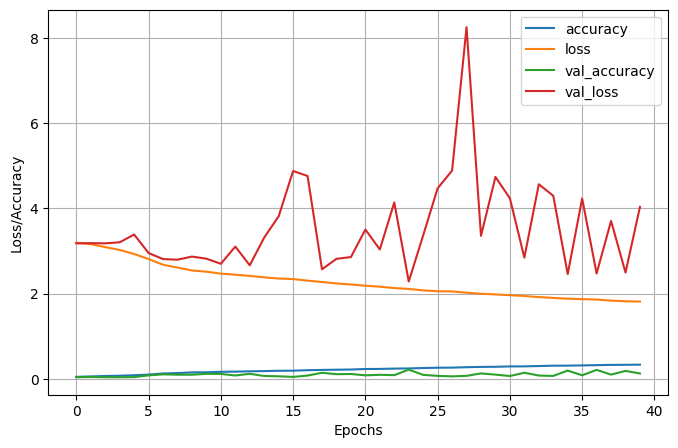

In [99]:
# Model building
class_24_model_BN = keras.models.Sequential([
    #Rescaling to add gray channel to input
    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),
    # 3 convolutional layers to get to atleast 0.85 train accuracy

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    # One dense layer to  bring condense all information and make global connections
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(24, activation='softmax')
])
class_24_model_BN.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history= class_24_model_BN.fit(x_75_train_cat, y_75_train_categorical_24,
          batch_size=150,
          epochs=40,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_24))
score = class_24_model_BN.evaluate(x_75_validation_cat, y_75_validation_categorical_24, verbose=0)
history_dict['bn_24']=history
mae_results.append(["bn_24", evaluate_circular_mae_cat(class_24_model_BN, x_75_validation_cat,  y_75_validation, factor24)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_model_BN, x_75_validation_cat, y_75_validation, factor24))

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()



#### Addition of additional dense layer at end

Epoch 1/20


/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.0431 - loss: 3.1844 - val_accuracy: 0.0358 - val_loss: 3.1780
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0929 - loss: 2.9397 - val_accuracy: 0.0710 - val_loss: 3.0675
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2049 - loss: 2.3394 - val_accuracy: 0.0932 - val_loss: 2.9483
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3110 - loss: 1.9321 - val_accuracy: 0.1673 - val_loss: 2.5806
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3973 - loss: 1.6490 - val_accuracy: 0.2321 - val_loss: 2.2040
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4836 - loss: 1.4041 - val_accuracy: 0.3463 - val_loss: 1.8016
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5500 - loss: 1.2195 - val_accuracy: 0.2895 - val_loss: 2.4739
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6059 - loss: 1.0670 - val_accuracy: 0.5870 - val_loss: 1

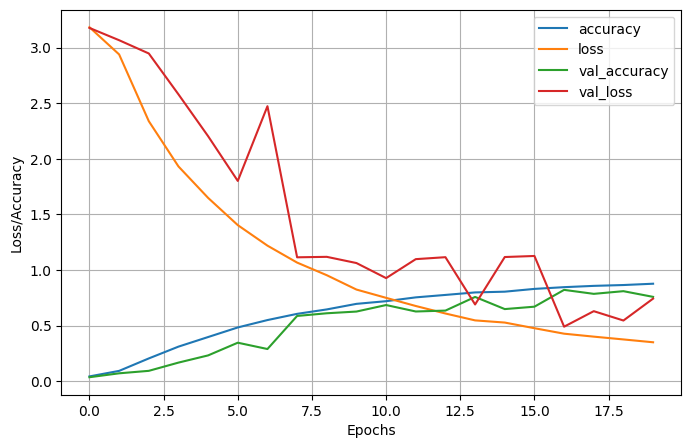

In [100]:
# Model building
class_24_model_BN_dense = keras.models.Sequential([
    #Rescaling to add gray channel to input
    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),
    # 3 convolutional layers to get to atleast 0.85 train accuracy

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    # One dense layer to  bring condense all information and make global connections
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(24, activation='softmax')
])
class_24_model_BN_dense.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history= class_24_model_BN_dense.fit(x_75_train_cat, y_75_train_categorical_24,
          batch_size=150,
          epochs=20,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_24))
score = class_24_model_BN_dense.evaluate(x_75_validation_cat, y_75_validation_categorical_24, verbose=0)
mae_results.append(["bn_24_dense", evaluate_circular_mae_cat(class_24_model_BN_dense, x_75_validation_cat,  y_75_validation, factor24)])

history_dict['bn_24_dense']=history

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_model_BN_dense, x_75_validation_cat, y_75_validation, factor24))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


#### Addition of another dense layer

/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.0433 - loss: 3.1845 - val_accuracy: 0.0346 - val_loss: 3.1780
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0952 - loss: 2.9286 - val_accuracy: 0.0772 - val_loss: 3.1427
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2191 - loss: 2.2507 - val_accuracy: 0.1463 - val_loss: 2.7966
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3495 - loss: 1.7965 - val_accuracy: 0.1698 - val_loss: 2.5501
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4728 - loss: 1.4436 - val_accuracy: 0.3099 - val_loss: 1.9736
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5615 - loss: 1.1831 - val_accuracy: 0.6228 - val_loss: 1.2152
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6323 - loss: 0.9894 - val_accuracy: 0.5938 - val_loss: 1.0949
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6847 - loss: 0.8491 - val_accuracy: 0.6833 - 

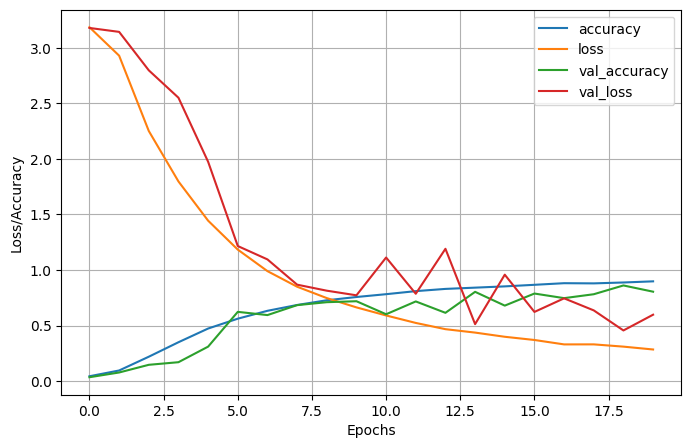

In [101]:
# Model building
class_24_model_BN_dense_2 = keras.models.Sequential([
    #Rescaling to add gray channel to input
    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),
    # 3 convolutional layers to get to atleast 0.85 train accuracy

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    # One dense layer to  bring condense all information and make global connections
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(24, activation='softmax')
])


class_24_model_BN_dense_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = class_24_model_BN_dense_2.fit(x_75_train_cat, y_75_train_categorical_24,
          batch_size=150,
          epochs=20,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_24))
score = class_24_model_BN_dense_2.evaluate(x_75_validation_cat, y_75_validation_categorical_24, verbose=0)
mae_results.append(["bn_24_dense_2", evaluate_circular_mae_cat(class_24_model_BN_dense_2, x_75_validation_cat,  y_75_validation, factor24)])

history_dict['bn_24_dense_2']=history

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_model_BN_dense_2, x_75_validation_cat, y_75_validation, factor24))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()



#### Higher filter count

/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.0501 - loss: 3.1794 - val_accuracy: 0.0586 - val_loss: 3.1752
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.1134 - loss: 2.8432 - val_accuracy: 0.1074 - val_loss: 3.0233
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.2229 - loss: 2.2643 - val_accuracy: 0.1210 - val_loss: 2.9257
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3161 - loss: 1.8969 - val_accuracy: 0.2284 - val_loss: 2.5262
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4029 - loss: 1.6302 - val_accuracy: 0.1481 - val_loss: 2.8132
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4856 - loss: 1.3969 - val_accuracy: 0.2340 - val_loss: 2.3642
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5582 - loss: 1.1934 - val_accuracy: 0.2068 - val_loss: 3.3155
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6165 - loss: 1.0420 - val_accuracy: 0.3963 - 

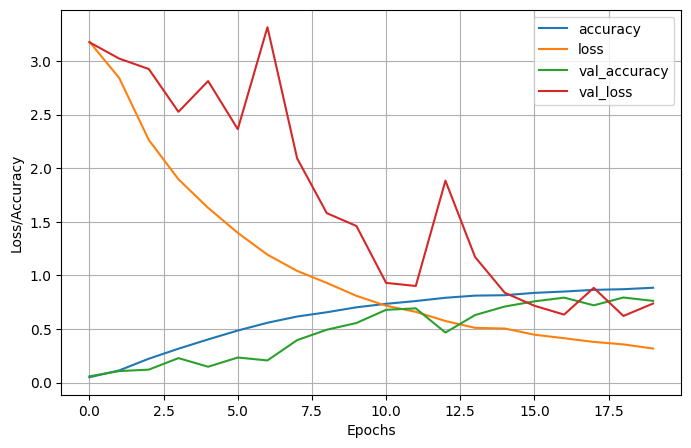

In [102]:
# Model with BatchNormalization and higher filter count in 3th conv layer 
class_24_model_BN_filt_inc = keras.models.Sequential([
    #Rescaling to add gray channel to input
    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),
    # 3 convolutional layers to get to atleast 0.85 train accuracy

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(256, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    # One dense layer to  bring condense all information and make global connections
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(24, activation='softmax')
])
class_24_model_BN_filt_inc.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = class_24_model_BN_filt_inc.fit(x_75_train_cat, y_75_train_categorical_24,
          batch_size=150,
          epochs=20,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_24))
score = class_24_model_BN_filt_inc.evaluate(x_75_validation_cat, y_75_validation_categorical_24, verbose=0)
history_dict['bn_24_filt_inc']=history
mae_results.append(["bn_24_filt_inc", evaluate_circular_mae_cat(class_24_model_BN_filt_inc, x_75_validation_cat,  y_75_validation, factor24)])


print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_model_BN_filt_inc, x_75_validation_cat, y_75_validation, factor24))

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


#### smaller learning rate and more epochs to commomorate 

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.0437 - loss: 3.1902 - val_accuracy: 0.0389 - val_loss: 3.1780
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0634 - loss: 3.1456 - val_accuracy: 0.0574 - val_loss: 3.1658
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1209 - loss: 2.8112 - val_accuracy: 0.0599 - val_loss: 3.1547
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2167 - loss: 2.2715 - val_accuracy: 0.0802 - val_loss: 3.0873
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2966 - loss: 1.9463 - val_accuracy: 0.1012 - val_loss: 3.0753
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3698 - loss: 1.7235 - val_accuracy: 0.1401 - val_loss: 2.9017
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4431 - loss: 1.5240 - val_accuracy: 0.2809 - val_loss: 2.2468
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5014 - loss: 1.3543 - val_accuracy: 0.4414 - 

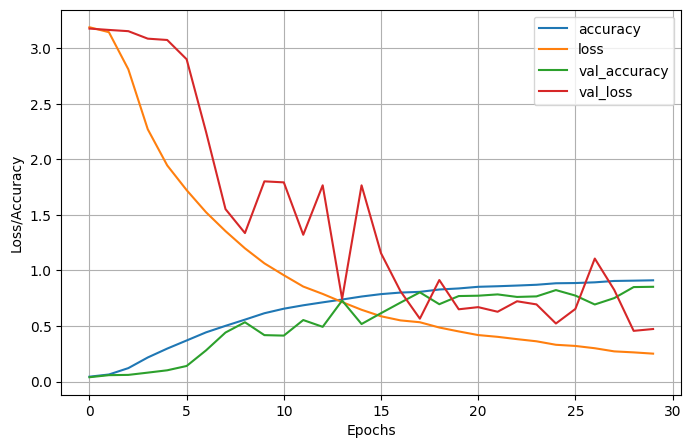

In [103]:
# Model with BN and lowered learning rate 
class_24_model_BN_lowlearnrate= keras.models.Sequential([
    keras.layers.Input(shape=(75,75,1)),

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    # One dense layer to  bring condense all information and make global connections
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(24, activation='softmax')
])

opt = keras.optimizers.Adam(learning_rate=0.0005)
class_24_model_BN_lowlearnrate.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history = class_24_model_BN_lowlearnrate.fit(x_75_train_cat, y_75_train_categorical_24,
          batch_size=150,
          epochs=30,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_24))
score = class_24_model_BN_lowlearnrate.evaluate(x_75_validation_cat, y_75_validation_categorical_24, verbose=0)
history_dict['bn_24_lowlearnrate']=history
mae_results.append(["bn_24_lowlearnrate", evaluate_circular_mae_cat(class_24_model_BN_lowlearnrate, x_75_validation_cat,  y_75_validation, factor24)])


print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_model_BN_lowlearnrate, x_75_validation_cat, y_75_validation, factor24))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


#### Switch of BN layer

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.0415 - loss: 3.1859 - val_accuracy: 0.0389 - val_loss: 3.1781
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0691 - loss: 3.0826 - val_accuracy: 0.0358 - val_loss: 3.3413
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1778 - loss: 2.4664 - val_accuracy: 0.0438 - val_loss: 3.7712
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2730 - loss: 2.0399 - val_accuracy: 0.0790 - val_loss: 3.3075
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3369 - loss: 1.8228 - val_accuracy: 0.1438 - val_loss: 2.6719
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3930 - loss: 1.6488 - val_accuracy: 0.2790 - val_loss: 2.0747
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4636 - loss: 1.4651 - val_accuracy: 0.1611 - val_loss: 3.7452
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5152 - loss: 1.3220 - val_accuracy: 0.3062 - 

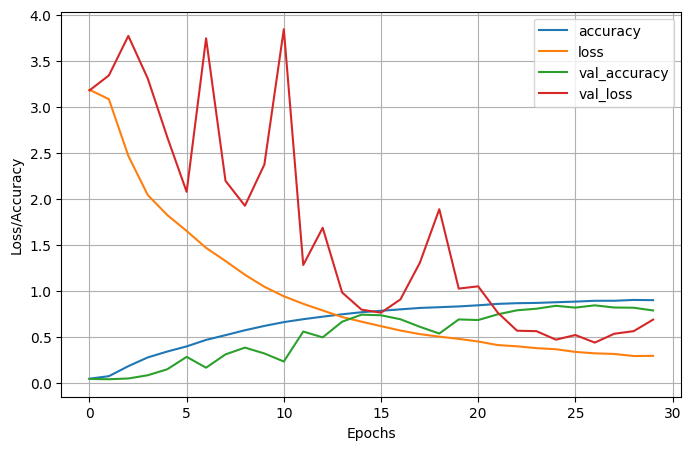

In [104]:
class_24_model_BN_diffpos= keras.models.Sequential([
    keras.layers.Input(shape=(75,75,1)),

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    # One dense layer to  bring condense all information and make global connections
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(24, activation='softmax')
])

opt = keras.optimizers.Adam(learning_rate=0.0005)
class_24_model_BN_diffpos.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history = class_24_model_BN_diffpos.fit(x_75_train_cat, y_75_train_categorical_24,
          batch_size=150,
          epochs=30,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_24))
score = class_24_model_BN_diffpos.evaluate(x_75_validation_cat, y_75_validation_categorical_24, verbose=0)
history_dict['bn_24_diffpos']=history
mae_results.append(["bn_24_diffpos", evaluate_circular_mae_cat(class_24_model_BN_diffpos, x_75_validation_cat,  y_75_validation, factor24)])



print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_model_BN_diffpos, x_75_validation_cat, y_75_validation, factor24))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


### Model 15 minute intervals (48 groups)

Once again without  batch normalization does not work 

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.0197 - loss: 3.8720 - val_accuracy: 0.0228 - val_loss: 3.8718
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0206 - loss: 3.8714 - val_accuracy: 0.0228 - val_loss: 3.8726
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0204 - loss: 3.8715 - val_accuracy: 0.0117 - val_loss: 3.8727
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0276 - loss: 3.8441 - val_accuracy: 0.0364 - val_loss: 3.7471
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0593 - loss: 3.5240 - val_accuracy: 0.1093 - val_loss: 3.1648
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1294 - loss: 2.9601 - val_accuracy: 0.2111 - val_loss: 2.4770
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2073 - loss: 2.4924 - val_accuracy: 0.2938 - val_loss: 2.1220
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2678 - loss: 2.2161 - val_accuracy: 0.3426 - 

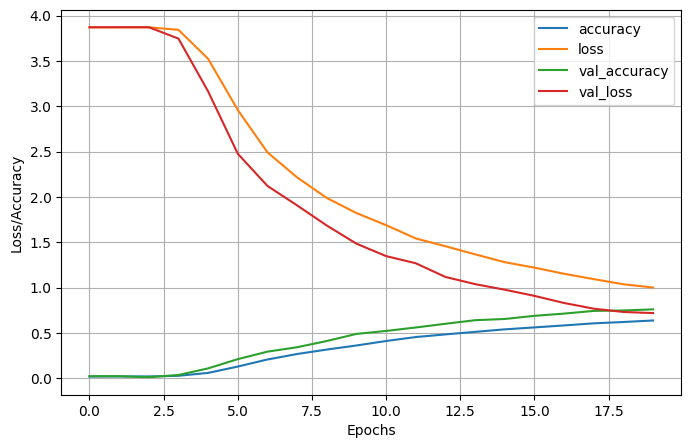

In [105]:
# Model building
class_48_model = keras.models.Sequential([
    keras.layers.Input(shape=(75,75,1)),
    # 3 convolutional layers to sequentially learn edges and what not
    keras.layers.Conv2D(16, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    # dropout to bring test accuray on par with train accuracy
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    # One dense layer to  bring condense all information and make global connections
    keras.layers.Dense(128, activation='relu'),
    # Second layer to connect important concepts
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(48, activation='softmax')
])
class_48_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = class_48_model.fit(x_75_train_cat, y_75_train_categorical_48,
        batch_size=150,
        epochs=20,
        verbose=1,
        validation_data=(x_75_validation_cat, y_75_validation_categorical_48))
score = class_48_model.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_48_model, x_75_validation_cat, y_75_validation, factor48))
history_dict['base_48']=history
mae_results.append(["base_48", evaluate_circular_mae_cat(class_48_model, x_75_validation_cat,  y_75_validation, factor48)])

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()



#### Batch Normalization

/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.0260 - loss: 3.8579 - val_accuracy: 0.0241 - val_loss: 3.8611
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.0909 - loss: 3.3011 - val_accuracy: 0.0543 - val_loss: 3.6496
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1999 - loss: 2.5396 - val_accuracy: 0.0938 - val_loss: 3.2822
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2822 - loss: 2.1252 - val_accuracy: 0.1494 - val_loss: 2.8617
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3362 - loss: 1.9059 - val_accuracy: 0.2827 - val_loss: 2.2664
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3863 - loss: 1.7349 - val_accuracy: 0.2031 - val_loss: 2.7427
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4292 - loss: 1.5839 - val_accuracy: 0.3414 - val_loss: 1.9189
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4804 - loss: 1.4497 - val_accuracy: 0.3253 - 

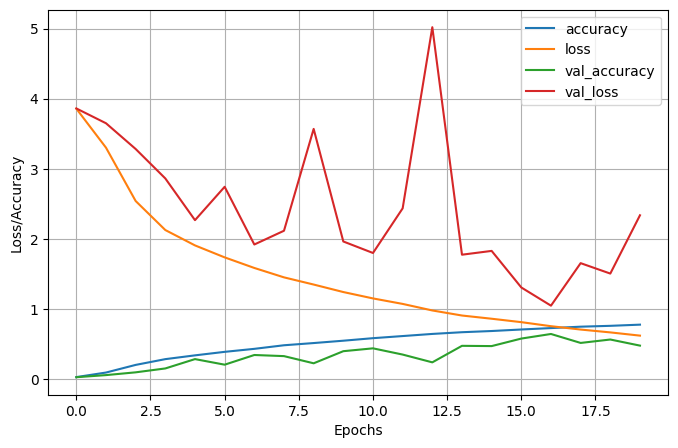

In [106]:
# Base BN model
class_48_model_BN= keras.models.Sequential([
    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(48, activation='softmax')
])

opt = keras.optimizers.Adam(learning_rate=0.001)
class_48_model_BN.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history = class_48_model_BN.fit(x_75_train_cat, y_75_train_categorical_48,
          batch_size=150,
          epochs=20,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_48))
score = class_48_model_BN.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
history_dict['bn_48']=history
mae_results.append(["bn_48", evaluate_circular_mae_cat(class_48_model_BN, x_75_validation_cat,  y_75_validation, factor48)])


print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_48_model_BN, x_75_validation_cat, y_75_validation, factor48))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


#### additional dense layer

/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.0215 - loss: 3.8781 - val_accuracy: 0.0179 - val_loss: 3.8717
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.0353 - loss: 3.7907 - val_accuracy: 0.0333 - val_loss: 3.8102
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1405 - loss: 2.9108 - val_accuracy: 0.0389 - val_loss: 3.8123
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2624 - loss: 2.1833 - val_accuracy: 0.0648 - val_loss: 3.6683
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3349 - loss: 1.8860 - val_accuracy: 0.0870 - val_loss: 3.6455
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4001 - loss: 1.6646 - val_accuracy: 0.2086 - val_loss: 2.5659
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4597 - loss: 1.4670 - val_accuracy: 0.2870 - val_loss: 2.3008
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5183 - loss: 1.3028 - val_accuracy: 0.4117 - 

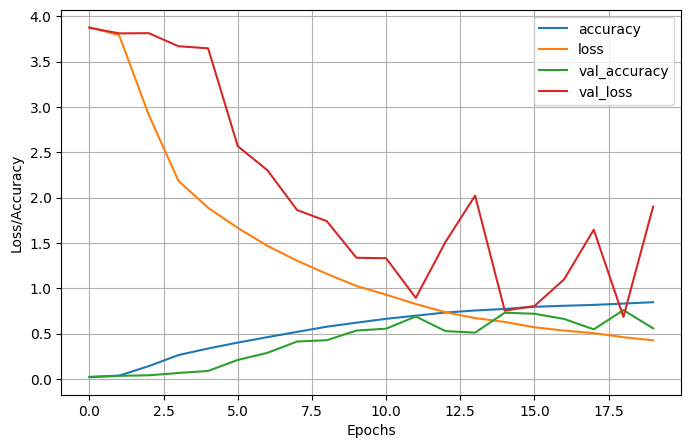

In [107]:
class_48_model_BN_dense= keras.models.Sequential([
    #Rescaling to add gray channel to input
    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),
    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(48, activation='softmax')
])

opt = keras.optimizers.Adam(learning_rate=0.001)
class_48_model_BN_dense.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history = class_48_model_BN_dense.fit(x_75_train_cat, y_75_train_categorical_48,
          batch_size=150,
          epochs=20,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_48))
score = class_48_model_BN_dense.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
history_dict['bn_48_dense']=history
mae_results.append(["bn_48_dense", evaluate_circular_mae_cat(class_48_model_BN_dense, x_75_validation_cat,  y_75_validation, factor48)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_48_model_BN_dense, x_75_validation_cat, y_75_validation, factor48))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


#### Additional conv2d layer with more filters 

/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.0310 - loss: 3.8118 - val_accuracy: 0.0154 - val_loss: 4.1175
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1193 - loss: 3.0132 - val_accuracy: 0.0247 - val_loss: 5.3483
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2404 - loss: 2.2405 - val_accuracy: 0.0302 - val_loss: 4.4275
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3119 - loss: 1.9526 - val_accuracy: 0.1568 - val_loss: 2.7982
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3712 - loss: 1.7439 - val_accuracy: 0.0426 - val_loss: 7.1897
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4222 - loss: 1.5606 - val_accuracy: 0.0877 - val_loss: 4.5893
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5005 - loss: 1.3566 - val_accuracy: 0.1765 - val_loss: 3.3463
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5611 - loss: 1.1758 - val_accuracy: 0.1358 - 

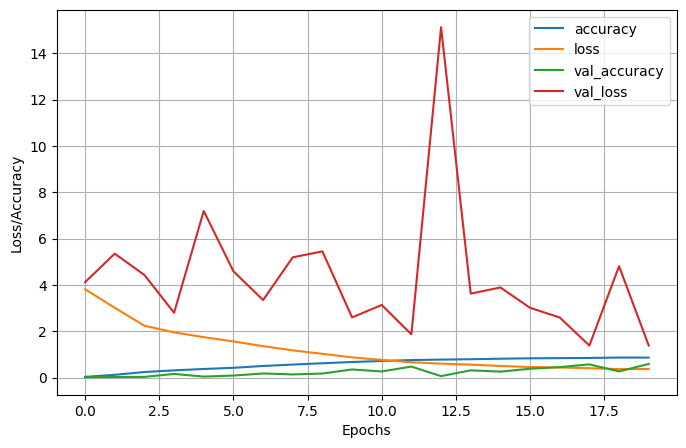

In [108]:
# Model with BN with added conv2d layer
class_48_model_BN2= keras.models.Sequential([
    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(256, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(48, activation='softmax')
])

opt = keras.optimizers.Adam(learning_rate=0.001)
class_48_model_BN2.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history = class_48_model_BN2.fit(x_75_train_cat, y_75_train_categorical_48,
          batch_size=150,
          epochs=20,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_48))
score = class_48_model_BN2.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
history_dict['bn_48_dense_conv_add']=history
mae_results.append(["bn_48_dense_conv_add", evaluate_circular_mae_cat(class_48_model_BN2, x_75_validation_cat,  y_75_validation, factor48)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_48_model_BN2, x_75_validation_cat, y_75_validation, factor48))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


#### Model decrease in learning rate 

Epoch 1/40


/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.0204 - loss: 3.8786 - val_accuracy: 0.0210 - val_loss: 3.8713
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0224 - loss: 3.8725 - val_accuracy: 0.0198 - val_loss: 3.8711
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0255 - loss: 3.8704 - val_accuracy: 0.0241 - val_loss: 3.8708
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0261 - loss: 3.8655 - val_accuracy: 0.0315 - val_loss: 3.8699
Epoch 5/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0290 - loss: 3.8548 - val_accuracy: 0.0259 - val_loss: 3.8649
Epoch 6/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0369 - loss: 3.8087 - val_accuracy: 0.0272 - val_loss: 3.8637
Epoch 7/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0641 - loss: 3.6327 - val_accuracy: 0.0198 - val_loss: 5.2821
Epoch 8/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1107 - loss: 3.2332 - val_accuracy: 0.0222 - val_loss: 8

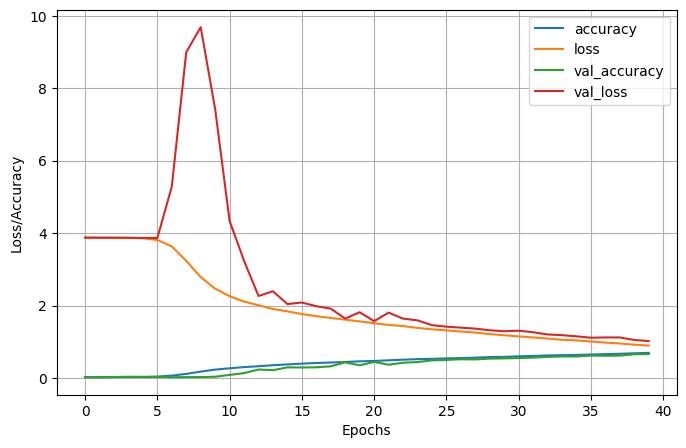

In [109]:
# Model with BN with added conv2d layer
class_48_model_BN3= keras.models.Sequential([

    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),
    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(48, activation='softmax')
])

opt = keras.optimizers.Adam(learning_rate=0.0001) 
class_48_model_BN3.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history = class_48_model_BN3.fit(x_75_train_cat, y_75_train_categorical_48,
          batch_size=150,
          epochs=40,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_48))
score = class_48_model_BN3.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
history_dict['bn_48_dense_lowerlearn']=history
mae_results.append(["bn_48_dense_lowerlearn", evaluate_circular_mae_cat(class_48_model_BN3, x_75_validation_cat,  y_75_validation, factor48)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_48_model_BN3, x_75_validation_cat, y_75_validation, factor48))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.0216 - loss: 6.1765 - val_accuracy: 0.0253 - val_loss: 4.2681
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0515 - loss: 4.1069 - val_accuracy: 0.0309 - val_loss: 4.4628
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1662 - loss: 3.3229 - val_accuracy: 0.0228 - val_loss: 4.9420
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2623 - loss: 2.7714 - val_accuracy: 0.0265 - val_loss: 4.9029
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3239 - loss: 2.4505 - val_accuracy: 0.0846 - val_loss: 3.7492
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3556 - loss: 2.2887 - val_accuracy: 0.2173 - val_loss: 2.8244
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3943 - loss: 2.1296 - val_accuracy: 0.2759 - val_loss: 2.6928
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4339 - loss: 1.9842 - val_accuracy: 0.1432 - 

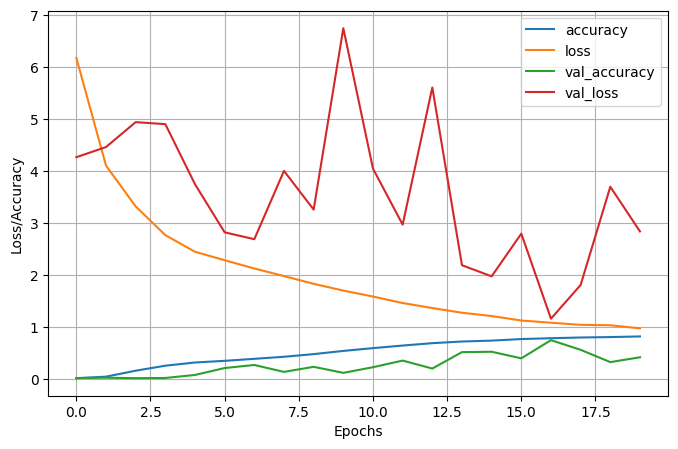

In [110]:
# Model with BN with L1 regularization
class_48_model_BN4= keras.models.Sequential([
    #Rescaling to add gray channel to input
    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),
    # 3 convolutional layers to get to atleast 0.85 train accuracy

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(256, (3,3),
                        kernel_regularizer=keras.regularizers.l1(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(48, activation='softmax')
])

opt = keras.optimizers.Adam(learning_rate=0.001) 
class_48_model_BN4.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history= class_48_model_BN4.fit(x_75_train_cat, y_75_train_categorical_48,
          batch_size=150,
          epochs=20,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_48))
score = class_48_model_BN4.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
history_dict['bn_48_dense_l1reg']=history
mae_results.append(["bn_48_dense_l1reg", evaluate_circular_mae_cat(class_48_model_BN4, x_75_validation_cat,  y_75_validation, factor48)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_48_model_BN4, x_75_validation_cat, y_75_validation, factor48))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


### 10 minute intervals (72 groups)

/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.0141 - loss: 4.3044 - val_accuracy: 0.0105 - val_loss: 4.2765
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0167 - loss: 4.2725 - val_accuracy: 0.0093 - val_loss: 4.2778
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0210 - loss: 4.1618 - val_accuracy: 0.0086 - val_loss: 4.2837
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0547 - loss: 3.7634 - val_accuracy: 0.0154 - val_loss: 4.7656
Epoch 5/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.1746 - loss: 2.7705 - val_accuracy: 0.0352 - val_loss: 4.2069
Epoch 6/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.2665 - loss: 2.2260 - val_accuracy: 0.2025 - val_loss: 2.5884
Epoch 7/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.3139 - loss: 1.9858 - val_accuracy: 0.3389 - val_loss: 1.9584
Epoch 8/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3602 - loss: 1.8302 - val_accuracy: 0.2827 - 

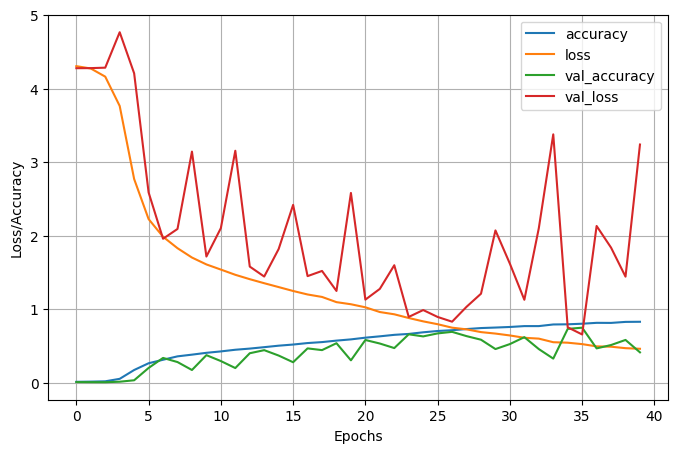

In [111]:
# Model with BN and lowered learning rate
class_72_model_BN= keras.models.Sequential([
    #Rescaling to add gray channel to input
    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),
    # 3 convolutional layers to get to atleast 0.85 train accuracy

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.BatchNormalization(),

    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(72, activation='softmax')
])

opt = keras.optimizers.Adam(learning_rate=0.0005)
class_72_model_BN.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history = class_72_model_BN.fit(x_75_train_cat, y_75_train_categorical_72,
          batch_size=150,
          epochs=40,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_72))
score = class_72_model_BN.evaluate(x_75_validation_cat, y_75_validation_categorical_72, verbose=0)
history_dict['bn_72']=history
mae_results.append(["bn_72", evaluate_circular_mae_cat(class_72_model_BN, x_75_validation_cat,  y_75_validation, factor72)])


print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_72_model_BN, x_75_validation_cat, y_75_validation, factor72))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/35
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.0132 - loss: 5.4025 - val_accuracy: 0.0148 - val_loss: 4.5873
Epoch 2/35
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0139 - loss: 4.3739 - val_accuracy: 0.0111 - val_loss: 4.2882
Epoch 3/35
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0141 - loss: 4.2822 - val_accuracy: 0.0086 - val_loss: 4.2820
Epoch 4/35
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0136 - loss: 4.2809 - val_accuracy: 0.0086 - val_loss: 4.2823
Epoch 5/35
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0130 - loss: 4.2809 - val_accuracy: 0.0086 - val_loss: 4.2827
Epoch 6/35
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0123 - loss: 4.2809 - val_accuracy: 0.0086 - val_loss: 4.2829
Epoch 7/35
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0123 - loss: 4.2808 - val_accuracy: 0.0086 - val_loss: 4.2832
Epoch 8/35
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0129 - loss: 4.2808 - val_accuracy: 0.0086 - 

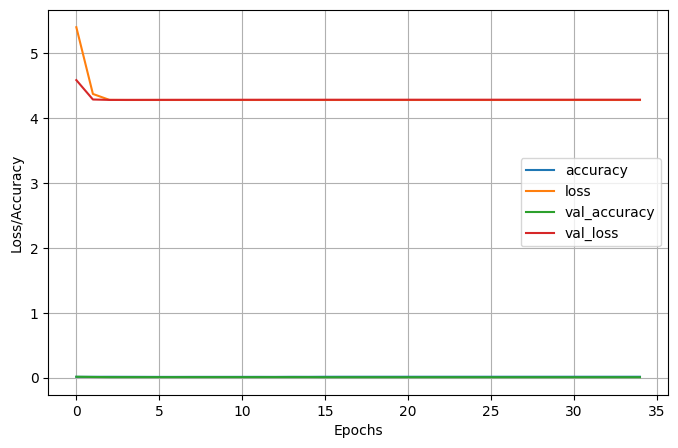

In [112]:
class_72_L1reg= keras.models.Sequential([
    #Rescaling to add gray channel to input
    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),
    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3),
                        kernel_regularizer=keras.regularizers.l1(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(72, activation='softmax')
])

opt = keras.optimizers.Adam(learning_rate=0.0005)
class_72_L1reg.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history= class_72_L1reg.fit(x_75_train_cat, y_75_train_categorical_72,
          batch_size=150,
          epochs=35,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_72))
score = class_72_L1reg.evaluate(x_75_validation_cat, y_75_validation_categorical_72, verbose=0)
history_dict['bn_72_l1reg']=history
mae_results.append(["bn_72_l1reg", evaluate_circular_mae_cat(class_72_L1reg, x_75_validation_cat, y_75_validation, factor72)])


print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_72_L1reg, x_75_validation_cat, y_75_validation, factor72))
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


/vol/home/s4506987/miniconda3/envs/TFenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.0132 - loss: 5.7471 - val_accuracy: 0.0160 - val_loss: 4.8169
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0153 - loss: 4.5088 - val_accuracy: 0.0136 - val_loss: 4.3618
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0130 - loss: 4.3277 - val_accuracy: 0.0136 - val_loss: 4.3053
Epoch 4/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0125 - loss: 4.2937 - val_accuracy: 0.0136 - val_loss: 4.2878
Epoch 5/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0136 - loss: 4.2840 - val_accuracy: 0.0074 - val_loss: 4.2839
Epoch 6/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0147 - loss: 4.2817 - val_accuracy: 0.0074 - val_loss: 4.2831
Epoch 7/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0146 - loss: 4.2812 - val_accuracy: 0.0074 - val_loss: 4.2833
Epoch 8/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0147 - loss: 4.2811 - val_accuracy: 0.0074 - 

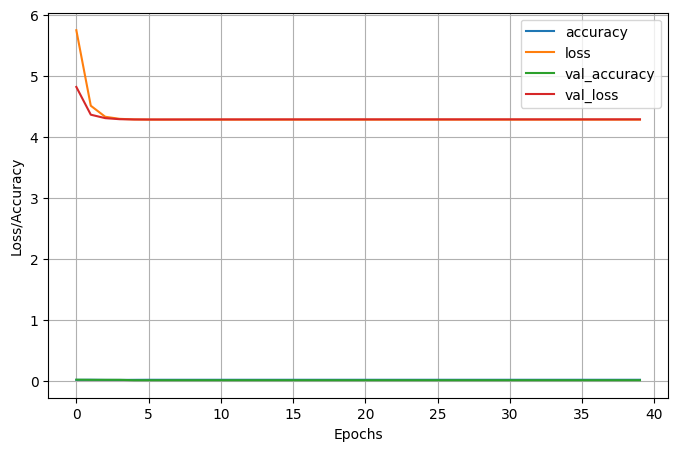

In [113]:
# Model with BN and lowered learning rate
class_72_L1reg_2= keras.models.Sequential([
    #Rescaling to add gray channel to input
    keras.layers.Rescaling(1./1, input_shape=(75, 75, 1)),
    # 3 convolutional layers to get to atleast 0.85 train accuracy

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3),
                        kernel_regularizer=keras.regularizers.l1(0.001)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3),
                        kernel_regularizer=keras.regularizers.l1(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    # One dense layer to  bring condense all information and make global connections
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(72, activation='softmax')
])

opt = keras.optimizers.Adam(learning_rate=0.0005)
class_72_L1reg_2.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history_L1_72_2 = class_72_L1reg_2.fit(x_75_train_cat, y_75_train_categorical_72,
          batch_size=150,
          epochs=40,
          verbose=1,
          validation_data=(x_75_validation_cat, y_75_validation_categorical_72))
score = class_72_L1reg_2.evaluate(x_75_validation_cat, y_75_validation_categorical_72, verbose=0)
history_dict['bn_72_l1reg_2']=history
mae_results.append(["bn_72_l1reg_2", evaluate_circular_mae_cat(class_72_L1reg_2, x_75_validation_cat, y_75_validation, factor72)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_72_L1reg_2, x_75_validation_cat, y_75_validation, factor72))
pd.DataFrame(history_L1_72_2.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()


### Transfer Learning chain

#### Base model, keep all layers of previous model trainable

In [114]:
for i, layer in enumerate(class_24_model_BN_lowlearnrate.layers):
    print(i, layer.name, layer.output_shape if hasattr(layer, "output_shape") else "no output")


0 conv2d_72 no output
1 activation_62 no output
2 max_pooling2d_72 no output
3 conv2d_73 no output
4 activation_63 no output
5 max_pooling2d_73 no output
6 conv2d_74 no output
7 batch_normalization_23 no output
8 activation_64 no output
9 max_pooling2d_74 no output
10 dropout_48 no output
11 flatten_23 no output
12 dense_195 no output
13 dense_196 no output
14 dense_197 no output


Epoch 1/20
96/98 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0232 - loss: 7.8272

2025-11-05 18:28:24.628150: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-05 18:28:24.897727: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1633', 12 bytes spill stores, 12 bytes spill loads



98/98 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.0236 - loss: 5.6066 - val_accuracy: 0.0253 - val_loss: 3.9072
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0294 - loss: 3.9183 - val_accuracy: 0.0253 - val_loss: 3.8568
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0343 - loss: 3.8448 - val_accuracy: 0.0364 - val_loss: 3.8050
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0429 - loss: 3.7722 - val_accuracy: 0.0716 - val_loss: 3.6123
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0660 - loss: 3.6186 - val_accuracy: 0.0673 - val_loss: 3.5194
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0924 - loss: 3.3561 - val_accuracy: 0.0679 - val_loss: 3.4435
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1318 - loss: 3.0459 - val_accuracy: 0.0895 - val_loss: 3.5306
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1851 - loss: 2.7172 - val_accuracy: 0.1352 - val_loss: 3

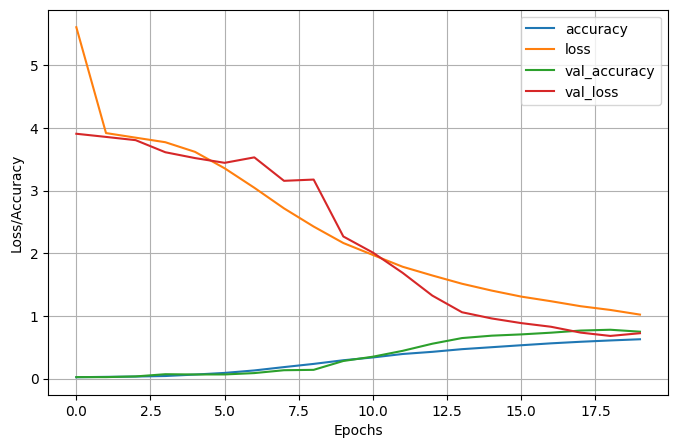

In [115]:
# Call the model once to define input/output
_ = class_24_model_BN_lowlearnrate(tf.zeros((1, 75, 75, 1)))

feature_extractor = keras.Sequential(class_24_model_BN_lowlearnrate.layers[:-1])


# Build functional model
inputs = keras.Input(shape=(75, 75, 1))
features = feature_extractor(inputs)

# Add new dense layers for 48-class classification
x = keras.layers.Dense(256, activation='relu')(features)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs_48 = keras.layers.Dense(48, activation='softmax')(x)

class_24_to_48_model = keras.Model(inputs=inputs, outputs=outputs_48)

# Compile
class_24_to_48_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_24_48 = class_24_to_48_model.fit(
    x_75_train_cat, y_75_train_categorical_48,
    batch_size=150,
    epochs=20,
    verbose=1,
    validation_data=(x_75_validation_cat, y_75_validation_categorical_48)
)

# Evaluate
score = class_24_to_48_model.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
history_dict['24_to_48'] = history_24_48
mae_results.append(["24_to_48", evaluate_circular_mae_cat(class_24_to_48_model, x_75_validation_cat, y_75_validation, factor48)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_to_48_model, x_75_validation_cat, y_75_validation, factor48))

# Plot training curves
pd.DataFrame(history_24_48.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.show()


#### Freeze first 2 convolutional blocks

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.0345 - loss: 5.1215 - val_accuracy: 0.0383 - val_loss: 3.7119
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0630 - loss: 3.6974 - val_accuracy: 0.0895 - val_loss: 3.3949
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1052 - loss: 3.3585 - val_accuracy: 0.1914 - val_loss: 2.8667
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1744 - loss: 2.9074 - val_accuracy: 0.2778 - val_loss: 2.4305
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2489 - loss: 2.4839 - val_accuracy: 0.4191 - val_loss: 1.8773
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3108 - loss: 2.1333 - val_accuracy: 0.5117 - val_loss: 1.5487
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3763 - loss: 1.8657 - val_accuracy: 0.5975 - val_loss: 1.3017
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4245 - loss: 1.6838 - val_accuracy: 0.6481 - val

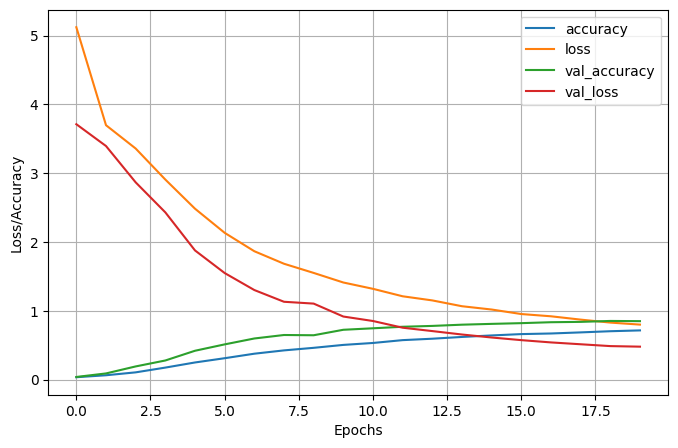

In [116]:
# Call the model once to define input/output
_ = class_24_model_BN_lowlearnrate(tf.zeros((1, 75, 75, 1)))

feature_extractor = keras.Sequential(class_24_model_BN_lowlearnrate.layers[:-1])


# Freeze early layers
for layer in feature_extractor.layers[:5]:
    layer.trainable = False

# Build functional model
inputs = keras.Input(shape=(75, 75, 1))
features = feature_extractor(inputs)

# Add new dense layers for 48-class classification
x = keras.layers.Dense(256, activation='relu')(features)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs_48 = keras.layers.Dense(48, activation='softmax')(x)

class_24_to_48_model_freeze = keras.Model(inputs=inputs, outputs=outputs_48)

# Compile
class_24_to_48_model_freeze.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_24_48 = class_24_to_48_model_freeze.fit(
    x_75_train_cat, y_75_train_categorical_48,
    batch_size=150,
    epochs=20,
    verbose=1,
    validation_data=(x_75_validation_cat, y_75_validation_categorical_48)
)

# Evaluate
score = class_24_to_48_model_freeze.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
history_dict['24_to_48_freeze'] = history_24_48
mae_results.append(["24_to_48_freeze", evaluate_circular_mae_cat(class_24_to_48_model_freeze, x_75_validation_cat, y_75_validation, factor48)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_to_48_model_freeze, x_75_validation_cat, y_75_validation, factor48))

# Plot training curves
pd.DataFrame(history_24_48.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.show()


#### Freeze all convolutional blocks 

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.0365 - loss: 5.1266 - val_accuracy: 0.1198 - val_loss: 3.3300
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0957 - loss: 3.5383 - val_accuracy: 0.2500 - val_loss: 2.8062
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1671 - loss: 3.0078 - val_accuracy: 0.3735 - val_loss: 2.2435
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2444 - loss: 2.5100 - val_accuracy: 0.5167 - val_loss: 1.7380
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3226 - loss: 2.1378 - val_accuracy: 0.6000 - val_loss: 1.3965
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3933 - loss: 1.8376 - val_accuracy: 0.6667 - val_loss: 1.1682
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4446 - loss: 1.6257 - val_accuracy: 0.7056 - val_loss: 1.0198
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4947 - loss: 1.4547 - val_accuracy: 0.7377 - val_los

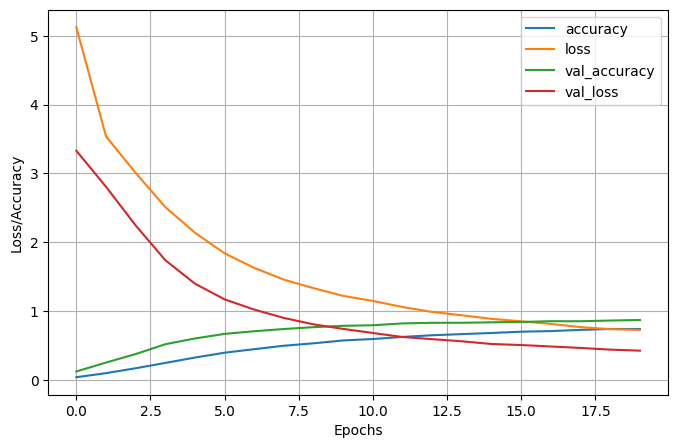

In [117]:
# Call the model once to define input/output
_ = class_24_model_BN_lowlearnrate(tf.zeros((1, 75, 75, 1)))

feature_extractor = keras.Sequential(class_24_model_BN_lowlearnrate.layers[:-1])


# Freeze early layers
for layer in feature_extractor.layers[:9]:
    layer.trainable = False

# Build functional model
inputs = keras.Input(shape=(75, 75, 1))
features = feature_extractor(inputs)

# Add new dense layers for 48-class classification
x = keras.layers.Dense(256, activation='relu')(features)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs_48 = keras.layers.Dense(48, activation='softmax')(x)

class_24_to_48_model_freeze2 = keras.Model(inputs=inputs, outputs=outputs_48)

# Compile
class_24_to_48_model_freeze2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_24_48 = class_24_to_48_model_freeze2.fit(
    x_75_train_cat, y_75_train_categorical_48,
    batch_size=150,
    epochs=20,
    verbose=1,
    validation_data=(x_75_validation_cat, y_75_validation_categorical_48)
)

# Evaluate
score = class_24_to_48_model_freeze2.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
history_dict['24_to_48_freeze2'] = history_24_48
mae_results.append(["24_to_48_freeze2", evaluate_circular_mae_cat(class_24_to_48_model_freeze2, x_75_validation_cat, y_75_validation, factor48)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_to_48_model_freeze2, x_75_validation_cat, y_75_validation, factor48))

# Plot training curves
pd.DataFrame(history_24_48.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.show()


#### Freeze no layers, remove dropout

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.1577 - loss: 3.4434 - val_accuracy: 0.3519 - val_loss: 2.2486
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5117 - loss: 1.6713 - val_accuracy: 0.6568 - val_loss: 1.2185
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7100 - loss: 1.0082 - val_accuracy: 0.7623 - val_loss: 0.8371
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7872 - loss: 0.7364 - val_accuracy: 0.8019 - val_loss: 0.6669
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8289 - loss: 0.5937 - val_accuracy: 0.8358 - val_loss: 0.5563
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8492 - loss: 0.5083 - val_accuracy: 0.8481 - val_loss: 0.5004
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8644 - loss: 0.4478 - val_accuracy: 0.8630 - val_loss: 0.4524
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8789 - loss: 0.4073 - val_accuracy: 0.8765 - val_loss

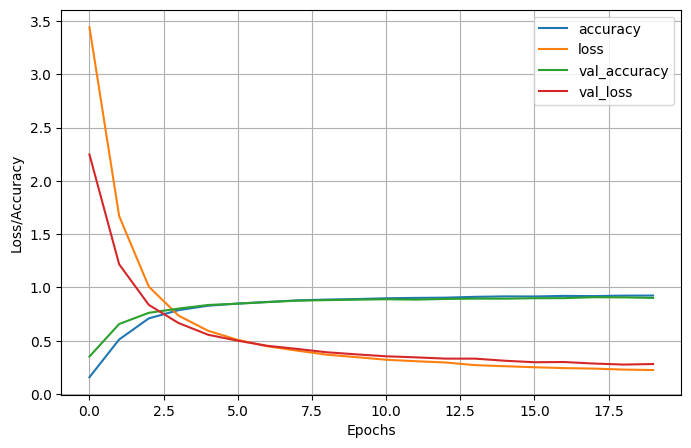

In [118]:
# Call the model once to define input/output
_ = class_24_model_BN_lowlearnrate(tf.zeros((1, 75, 75, 1)))

feature_extractor = keras.Sequential(class_24_model_BN_lowlearnrate.layers[:-1])


# Build functional model
inputs = keras.Input(shape=(75, 75, 1))
features = feature_extractor(inputs)

# Add new dense layers for 48-class classification
x = keras.layers.Dense(256, activation='relu')(features)
x = keras.layers.Dense(256, activation='relu')(x)
outputs_48 = keras.layers.Dense(48, activation='softmax')(x)

class_24_to_48_model = keras.Model(inputs=inputs, outputs=outputs_48)

# Compile
class_24_to_48_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_24_48 = class_24_to_48_model.fit(
    x_75_train_cat, y_75_train_categorical_48,
    batch_size=150,
    epochs=20,
    verbose=1,
    validation_data=(x_75_validation_cat, y_75_validation_categorical_48)
)

# Evaluate
score = class_24_to_48_model.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
history_dict['24_to_48_nodrouput'] = history_24_48
mae_results.append(["24_to_48_nodrouput", evaluate_circular_mae_cat(class_24_to_48_model, x_75_validation_cat, y_75_validation, factor48)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_to_48_model, x_75_validation_cat, y_75_validation, factor48))

# Plot training curves
pd.DataFrame(history_24_48.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.show()


#### Increased dense layers 

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.1900 - loss: 3.3174 - val_accuracy: 0.4259 - val_loss: 2.0174
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5979 - loss: 1.4255 - val_accuracy: 0.7222 - val_loss: 0.9907
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7785 - loss: 0.7878 - val_accuracy: 0.8111 - val_loss: 0.6616
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8399 - loss: 0.5574 - val_accuracy: 0.8389 - val_loss: 0.5344
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8658 - loss: 0.4500 - val_accuracy: 0.8586 - val_loss: 0.4652
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8814 - loss: 0.3866 - val_accuracy: 0.8685 - val_loss: 0.4245
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8959 - loss: 0.3408 - val_accuracy: 0.8840 - val_loss: 0.3707
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9016 - loss: 0.3101 - val_accuracy: 0.8821 - val_los

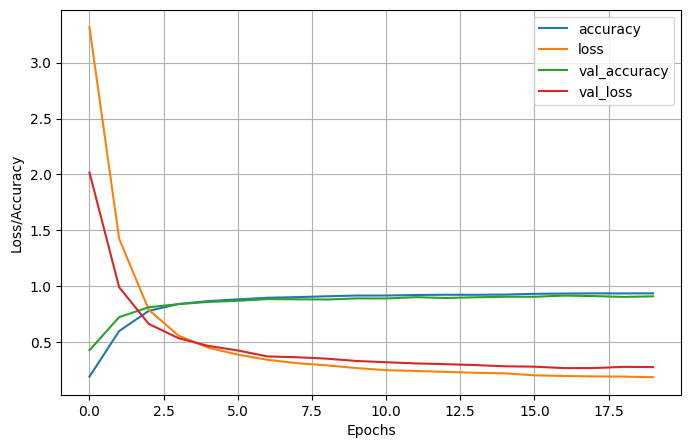

In [119]:
# Call the model once to define input/output
_ = class_24_model_BN_lowlearnrate(tf.zeros((1, 75, 75, 1)))

feature_extractor = keras.Sequential(class_24_model_BN_lowlearnrate.layers[:-1])


# Build functional model
inputs = keras.Input(shape=(75, 75, 1))
features = feature_extractor(inputs)

# Add new dense layers for 48-class classification
x = keras.layers.Dense(256, activation='relu')(features)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dense(256, activation='relu')(x)

outputs_48 = keras.layers.Dense(48, activation='softmax')(x)

class_24_to_48_model_best = keras.Model(inputs=inputs, outputs=outputs_48)

# Compile
class_24_to_48_model_best.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_24_48 = class_24_to_48_model_best.fit(
    x_75_train_cat, y_75_train_categorical_48,
    batch_size=150,
    epochs=20,
    verbose=1,
    validation_data=(x_75_validation_cat, y_75_validation_categorical_48)
)

# Evaluate
score = class_24_to_48_model_best.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
history_dict['24_to_48_moredense'] = history_24_48
mae_results.append(["24_to_48_moredense", evaluate_circular_mae_cat(class_24_to_48_model_best, x_75_validation_cat, y_75_validation, factor48)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_to_48_model_best, x_75_validation_cat, y_75_validation, factor48))

# Plot training curves
pd.DataFrame(history_24_48.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.show()


#### Lowered demse on last layer

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.1459 - loss: 3.7033 - val_accuracy: 0.3253 - val_loss: 2.4103
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4968 - loss: 1.7687 - val_accuracy: 0.6370 - val_loss: 1.2485
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7226 - loss: 0.9789 - val_accuracy: 0.7747 - val_loss: 0.8060
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8080 - loss: 0.6709 - val_accuracy: 0.8253 - val_loss: 0.6071
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8523 - loss: 0.5171 - val_accuracy: 0.8556 - val_loss: 0.5018
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8764 - loss: 0.4267 - val_accuracy: 0.8685 - val_loss: 0.4425
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8888 - loss: 0.3724 - val_accuracy: 0.8759 - val_loss: 0.3977
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9003 - loss: 0.3350 - val_accuracy: 0.8809 - val_los

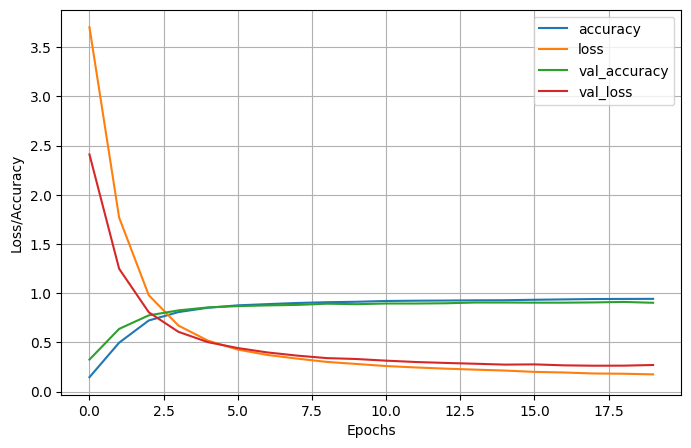

In [120]:
# Call the model once to define input/output
_ = class_24_model_BN_lowlearnrate(tf.zeros((1, 75, 75, 1)))

feature_extractor = keras.Sequential(class_24_model_BN_lowlearnrate.layers[:-1])


# Build functional model
inputs = keras.Input(shape=(75, 75, 1))
features = feature_extractor(inputs)

# Add new dense layers for 48-class classification
x = keras.layers.Dense(256, activation='relu')(features)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dense(128, activation='relu')(x)

outputs_48 = keras.layers.Dense(48, activation='softmax')(x)

class_24_to_48_model = keras.Model(inputs=inputs, outputs=outputs_48)

# Compile
class_24_to_48_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_24_48 = class_24_to_48_model.fit(
    x_75_train_cat, y_75_train_categorical_48,
    batch_size=150,
    epochs=20,
    verbose=1,
    validation_data=(x_75_validation_cat, y_75_validation_categorical_48)
)

# Evaluate
score = class_24_to_48_model.evaluate(x_75_validation_cat, y_75_validation_categorical_48, verbose=0)
history_dict['24_to_48_moredense_2'] = history_24_48
mae_results.append(["24_to_48_moredense_2", evaluate_circular_mae_cat(class_24_to_48_model, x_75_validation_cat, y_75_validation, factor48)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_to_48_model, x_75_validation_cat, y_75_validation, factor48))

# Plot training curves
pd.DataFrame(history_24_48.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.show()


#### 48_to_72 model

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.0926 - loss: 4.3333 - val_accuracy: 0.1994 - val_loss: 3.0521
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3713 - loss: 2.3051 - val_accuracy: 0.5216 - val_loss: 1.6887
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6150 - loss: 1.3357 - val_accuracy: 0.6988 - val_loss: 1.0442
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7398 - loss: 0.8992 - val_accuracy: 0.7741 - val_loss: 0.7702
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7938 - loss: 0.6929 - val_accuracy: 0.8000 - val_loss: 0.6362
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8128 - loss: 0.5948 - val_accuracy: 0.8327 - val_loss: 0.5555
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8309 - loss: 0.5218 - val_accuracy: 0.8401 - val_loss: 0.5078
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8442 - loss: 0.4763 - val_accuracy: 0.8494 - val_los

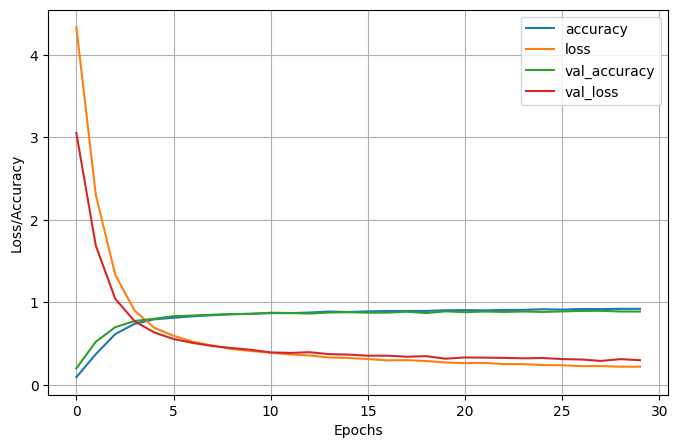

In [121]:
# Call once to ensure inputs are defined
_ = class_24_to_48_model_best(tf.zeros((1, 75, 75, 1)))

feature_extractor = keras.Sequential(class_24_model_BN_lowlearnrate.layers[:-1])

# Build functional model
inputs = keras.Input(shape=(75, 75, 1))
features = feature_extractor(inputs)

x = keras.layers.Dense(256, activation='relu')(features)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs_72 = keras.layers.Dense(72, activation='softmax')(x)

class_48_to_72_model = keras.Model(inputs=inputs, outputs=outputs_72)

class_48_to_72_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_48_72 = class_48_to_72_model.fit(
    x_75_train_cat, y_75_train_categorical_72,
    batch_size=150,
    epochs=30,
    verbose=1,
    validation_data=(x_75_validation_cat, y_75_validation_categorical_72)
)


score = class_48_to_72_model.evaluate(
    x_75_validation_cat, y_75_validation_categorical_72, verbose=0)
history_dict['48_to_72']=history_24_48
mae_results.append(["48_to_72", evaluate_circular_mae_cat(class_48_to_72_model, x_75_validation_cat, y_75_validation, factor72)])

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_48_to_72_model, x_75_validation_cat, y_75_validation, factor72))
pd.DataFrame(history_48_72.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()



### Summary table

In [122]:
###THIS CAN BE SAFELY DELTED, PURELY HERE FOR DEBUGGING PURPOSES
# mae_results.append(["48_to_72", evaluate_circular_mae_cat(class_48_to_72_model, x_75_validation_cat, y_75_validation, factor72)])
# mae_results.append(["24_to_48", evaluate_circular_mae_cat(class_24_to_48_model, x_75_validation_cat, y_75_validation, factor48)])
# mae_results.append(["bn_72_l1reg_2", evaluate_circular_mae_cat(class_72_L1reg_2, x_75_validation_cat, y_75_validation, factor72)])
# mae_results.append(["bn_72_l1reg", evaluate_circular_mae_cat(class_72_L1reg, x_75_validation_cat, y_75_validation, factor72)])
# mae_results.append(["bn_72", evaluate_circular_mae_cat(class_72_model_BN, x_75_validation_cat,  y_75_validation, factor72)])
# mae_results.append(["bn_48_dense_l1reg", evaluate_circular_mae_cat(class_48_model_BN4, x_75_validation_cat,  y_75_validation, factor48)])
# mae_results.append(["bn_48_dense_lowerlearn", evaluate_circular_mae_cat(class_48_model_BN3, x_75_validation_cat,  y_75_validation, factor48)])
# mae_results.append(["bn_48_dense_conv_add", evaluate_circular_mae_cat(class_48_model_BN2, x_75_validation_cat,  y_75_validation, factor48)])
# mae_results.append(["bn_48_dense", evaluate_circular_mae_cat(class_48_model_BN_dense, x_75_validation_cat,  y_75_validation, factor48)])
# mae_results.append(["bn_48", evaluate_circular_mae_cat(class_48_model_BN, x_75_validation_cat,  y_75_validation, factor48)])
# mae_results.append(["base_48", evaluate_circular_mae_cat(class_48_model, x_75_validation_cat,  y_75_validation, factor48)])
# mae_results.append(["bn_24_diffpos", evaluate_circular_mae_cat(class_24_model_BN_diffpos, x_75_validation_cat,  y_75_validation, factor24)])
# mae_results.append(["bn_24_lowlearnrate", evaluate_circular_mae_cat(class_24_model_BN_lowlearnrate, x_75_validation_cat,  y_75_validation, factor24)])
# mae_results.append(["bn_24_filt_inc", evaluate_circular_mae_cat(class_24_model_BN_filt_inc, x_75_validation_cat,  y_75_validation, factor24)])
# mae_results.append(["bn_24_dense_2", evaluate_circular_mae_cat(class_24_model_BN_dense_2, x_75_validation_cat,  y_75_validation, factor24)])
# mae_results.append(["bn_24_dense", evaluate_circular_mae_cat(class_24_model_BN_dense, x_75_validation_cat,  y_75_validation, factor24)])
# mae_results.append(["bn_24", evaluate_circular_mae_cat(class_24_model_BN, x_75_validation_cat,  y_75_validation, factor24)])
# mae_results.append(["base_24", evaluate_circular_mae_cat(class_24_model, x_75_validation_cat,  y_75_validation, factor24)])


In [123]:
summary = []

for name, hist in history_dict.items():
    metrics = hist.history.keys()

    # Safely get last values for loss/accuracy and val_loss/val_accuracy
    final_metrics = {m: hist.history[m][-1] for m in metrics if len(hist.history[m]) > 0}

    # Add model name
    final_metrics['model'] = name
    summary.append(final_metrics)

# Create DataFrame
df_summary = pd.DataFrame(summary)

# Reorder columns nicely
cols_order = ['model'] + [c for c in df_summary.columns if c != 'model']
df_summary = df_summary[cols_order]

# Sort or format
df_summary = df_summary.round(4)



In [124]:

# Convert each MAE to a scalar float
mae_results = [[name, float(np.ravel(mae)[0])] for name, mae in mae_results]

df_mae = pd.DataFrame(mae_results, columns=["model", "mae"])
df_mae["mae_minutes"] = (df_mae["mae"] * 720).round(3)  
df_full = pd.merge(df_summary, df_mae, on="model", how="left")

df_full


,model,accuracy,loss,val_accuracy,val_loss,mae,mae_minutes
0,base_24,0.8086,0.5398,0.8031,0.5566,0.033750,24.300
1,bn_24,0.3307,1.8126,0.1235,4.0350,0.142339,102.484
2,bn_24_dense,0.8770,0.3502,0.7586,0.7429,0.036269,26.114
3,bn_24_dense_2,0.8975,0.2842,0.8043,0.5973,0.037586,27.062
4,bn_24_filt_inc,0.8849,0.3176,0.7623,0.7378,0.033134,23.857
5,bn_24_lowlearnrate,0.9115,0.2512,0.8531,0.4729,0.030055,21.640
6,bn_24_diffpos,0.8959,0.2901,0.7840,0.6842,0.037527,27.020
7,base_48,0.6375,1.0012,0.7605,0.7193,0.030962,22.293
8,bn_48,0.7746,0.6179,0.4753,2.3360,0.066002,47.522
9,bn_48_dense,0.8455,0.4251,0.5568,1.8983,0.043823,31.552


In [125]:
df_full.sort_values('mae')

,model,accuracy,loss,val_accuracy,val_loss,mae,mae_minutes
22,48_to_72,0.9424,0.1749,0.9025,0.2702,0.009832,7.079
19,24_to_48_nodrouput,0.9246,0.2251,0.9019,0.2815,0.013799,9.935
20,24_to_48_moredense,0.9354,0.1847,0.9086,0.2753,0.014228,10.244
21,24_to_48_moredense_2,0.9424,0.1749,0.9025,0.2702,0.014290,10.289
18,24_to_48_freeze2,0.7377,0.7239,0.8685,0.4227,0.016132,11.615
17,24_to_48_freeze,0.7150,0.7993,0.8494,0.4787,0.017914,12.898
16,24_to_48,0.6291,1.0225,0.7500,0.7256,0.024798,17.854
5,bn_24_lowlearnrate,0.9115,0.2512,0.8531,0.4729,0.030055,21.640
7,base_48,0.6375,1.0012,0.7605,0.7193,0.030962,22.293
4,bn_24_filt_inc,0.8849,0.3176,0.7623,0.7378,0.033134,23.857


### Testing best models on test set

In [126]:
print('model trained on 24 categories with batch normalization')
print(class_24_model_BN_lowlearnrate.evaluate(x_75_test_cat, y_75_test_categorical_24))
print(evaluate_circular_mae_cat(class_24_model_BN_lowlearnrate, x_75_test_cat, y_75_test, factor24))
print('\n')

print('model trained on 72 categories with batch normalization')
print(class_72_model_BN.evaluate(x_75_test_cat, y_75_test_categorical_48))
print(evaluate_circular_mae_cat(class_48_model_BN, x_75_test_cat, y_75_test, factor48))
print('\n')

print('Transfer learning 24 to 48')
print(class_24_to_48_model.evaluate(x_75_test_cat, y_75_test_categorical_48))
print(evaluate_circular_mae_cat(class_24_to_48_model, x_75_test_cat, y_75_test, factor48))
print('\n')

print('Transfer learning 48 to 72')
print(class_48_to_72_model.evaluate(x_75_test_cat, y_75_test_categorical_72))
print(evaluate_circular_mae_cat(class_48_to_72_model, x_75_test_cat, y_75_test, factor72))



model trained on 24 categories with batch normalization
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3644 - loss: 8.1580
[8.157988548278809, 0.36444443464279175]
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
[np.float64(0.07812577160493828), np.float64(56.251)]


model trained on 72 categories with batch normalization
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0194 - loss: 33.4859
[33.48591995239258, 0.01944444514811039]
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
[np.float64(0.06651543209876543), np.float64(47.891)]


Transfer learning 24 to 48
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8506 - loss: 0.4280
[0.42795777320861816, 0.8505555391311646]
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
[np.float64(0.01877314814814815), np.float64(13.517)]


Transfer learning 48 to 72
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8950 - loss: 0.2854
[0.28543928265571594, 0.8949999809265137]
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
[np.float64(0.009400462962962961), np.float6

### Train, validate and test best models on larger 

In [127]:
# Load big dataset to start training
x_150 = np.load("A1_data_150/images.npy")
y_150 = np.load("A1_data_150/labels.npy")

# Normalise inputs, as in task 1
x_150 = x_150.astype('float32') / 255.0

# Split into training and test set and shuffle and since the datasets are ordered, it is recommended in the assignment spec to shuffle
x_150_train, x_150_test, y_150_train, y_150_test = train_test_split(x_150, y_150, test_size = 0.10, random_state = 2029197, shuffle = True)

# Split again into training-validation sets
x_150_train, x_150_validation, y_150_train, y_150_validation = train_test_split(x_150_train, y_150_train, test_size = 0.10, random_state = 202197)


# Given grayscale images it has to be added to the information i.e. shape from (n,75,75) to (n,75,75,1)
x_150_train_cat = np.expand_dims(x_150_train, axis=-1)
x_150_validation_cat = np.expand_dims(x_150_validation, axis=-1)
x_150_test_cat = np.expand_dims(x_150_test, axis=-1)

arrays = [y_150_train, y_150_validation, y_150_test]

# Make categorical tests for 30 (24 classes), 15 (48 classes) and 10 (72 classes) minutes intervals
y_150_categorical_24 = [split_into_bins(arr,30) for arr in arrays]
y_150_categorical_48 = [split_into_bins(arr,15) for arr in arrays]
y_150_categorical_72 = [split_into_bins(arr,10) for arr in arrays]

# Turn the string-based categories into factors in order to let our model know that this is a categorical variable
factor24 = LabelEncoder()
factor24.fit(np.concatenate(y_150_categorical_24))
y_150_train_categorical_24 = factor24.transform(y_150_categorical_24[0])
y_150_validation_categorical_24 = factor24.transform(y_150_categorical_24[1])
y_150_test_categorical_24 = factor24.transform(y_150_categorical_24[2])

factor48 = LabelEncoder()
factor48.fit(np.concatenate(y_150_categorical_48))
y_150_train_categorical_48 = factor48.transform(y_150_categorical_48[0])
y_150_validation_categorical_48 = factor48.transform(y_150_categorical_48[1])
y_150_test_categorical_48 = factor48.transform(y_150_categorical_48[2])


factor72 = LabelEncoder()
factor72.fit(np.concatenate(y_150_categorical_72))
y_150_train_categorical_72 = factor72.fit_transform(y_150_categorical_72[0])
y_150_validation_categorical_72 = factor72.transform(y_150_categorical_72[1])
y_150_test_categorical_72 = factor72.transform(y_150_categorical_72[2])

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.0487 - loss: 3.1941 - val_accuracy: 0.0444 - val_loss: 3.1771
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.0879 - loss: 3.0053 - val_accuracy: 0.0951 - val_loss: 3.1035
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.1664 - loss: 2.5819 - val_accuracy: 0.1012 - val_loss: 2.9695
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.2295 - loss: 2.3206 - val_accuracy: 0.0975 - val_loss: 2.8338
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.2941 - loss: 2.0867 - val_accuracy: 0.1160 - val_loss: 2.7828
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.3496 - loss: 1.8812 - val_accuracy: 0.1346 - val_loss: 3.0706
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.4071 - loss: 1.6888 - val_accuracy: 0.2093 - val_loss: 2.6579
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.4506 - loss: 1.5458 - val_accuracy: 0.2506 -

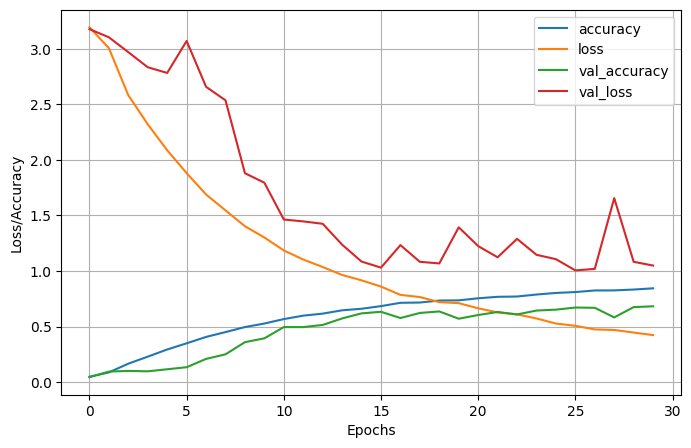

In [ ]:
class_24_model_BN_lowlearnrate= keras.models.Sequential([
    keras.layers.Input(shape=(150,150,1)),

    keras.layers.Conv2D(16, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3)),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    # One dense layer to  bring condense all information and make global connections
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(24, activation='softmax')
])

opt = keras.optimizers.Adam(learning_rate=0.0005)
class_24_model_BN_lowlearnrate.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

history = class_24_model_BN_lowlearnrate.fit(x_150_train_cat, y_150_train_categorical_24,
          batch_size=150,
          epochs=30,
          verbose=1,
          validation_data=(x_150_validation_cat, y_150_validation_categorical_24))
score = class_24_model_BN_lowlearnrate.evaluate(x_150_validation_cat, y_150_validation_categorical_24, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_model_BN_lowlearnrate, x_150_validation_cat, y_150_validation, factor24))

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.1008 - loss: 4.4056 - val_accuracy: 0.1827 - val_loss: 2.9596
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3496 - loss: 2.2173 - val_accuracy: 0.4130 - val_loss: 1.8600
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5953 - loss: 1.3168 - val_accuracy: 0.5043 - val_loss: 1.4754
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7378 - loss: 0.8693 - val_accuracy: 0.5994 - val_loss: 1.1808
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8104 - loss: 0.6378 - val_accuracy: 0.6667 - val_loss: 0.9583
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8512 - loss: 0.5013 - val_accuracy: 0.7123 - val_loss: 0.8200
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8673 - loss: 0.4312 - val_accuracy: 0.7420 - val_loss: 0.7576
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8843 - loss: 0.3708 - val_accuracy: 0.7549 - 

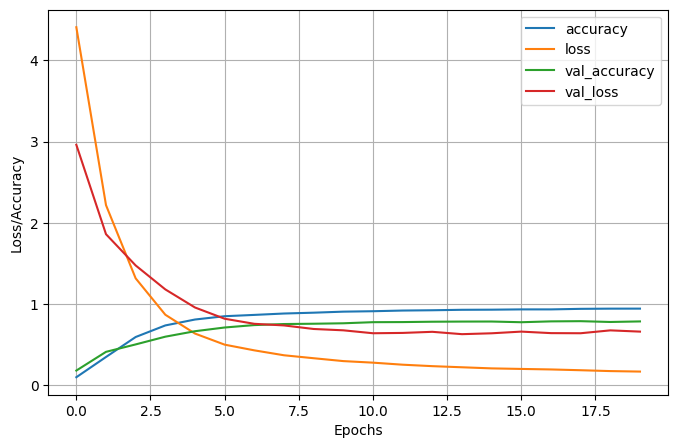

In [139]:
# Call the model once to define input/output
_ = class_24_model_BN_lowlearnrate(tf.zeros((1, 150, 150, 1)))

feature_extractor = keras.Sequential(class_24_model_BN_lowlearnrate.layers[:-1])


# Build functional model
inputs = keras.Input(shape=(150, 150, 1))
features = feature_extractor(inputs)

# Add new dense layers for 48-class classification
x = keras.layers.Dense(256, activation='relu')(features)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dense(256, activation='relu')(x)

outputs_48 = keras.layers.Dense(48, activation='softmax')(x)

class_24_to_48_model_best = keras.Model(inputs=inputs, outputs=outputs_48)

# Compile
class_24_to_48_model_best.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_24_48 = class_24_to_48_model_best.fit(
    x_150_train_cat, y_150_train_categorical_48,
    batch_size=150,
    epochs=20,
    verbose=1,
    validation_data=(x_150_validation_cat, y_150_validation_categorical_48)
)

# Evaluate
score = class_24_to_48_model_best.evaluate(x_150_validation_cat, y_150_validation_categorical_48, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_24_to_48_model_best, x_150_validation_cat, y_150_validation, factor48))

# Plot training curves
pd.DataFrame(history_24_48.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
plt.show()


Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.1754 - loss: 3.6536 - val_accuracy: 0.4043 - val_loss: 2.0373
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6075 - loss: 1.2761 - val_accuracy: 0.6179 - val_loss: 1.0988
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7494 - loss: 0.7431 - val_accuracy: 0.6895 - val_loss: 0.9177
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8005 - loss: 0.5801 - val_accuracy: 0.7154 - val_loss: 0.8400
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8222 - loss: 0.5054 - val_accuracy: 0.7426 - val_loss: 0.7654
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8382 - loss: 0.4546 - val_accuracy: 0.7549 - val_loss: 0.7317
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8486 - loss: 0.4168 - val_accuracy: 0.7506 - val_loss: 0.7272
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8637 - loss: 0.3781 - val_accuracy: 0.7296 - 

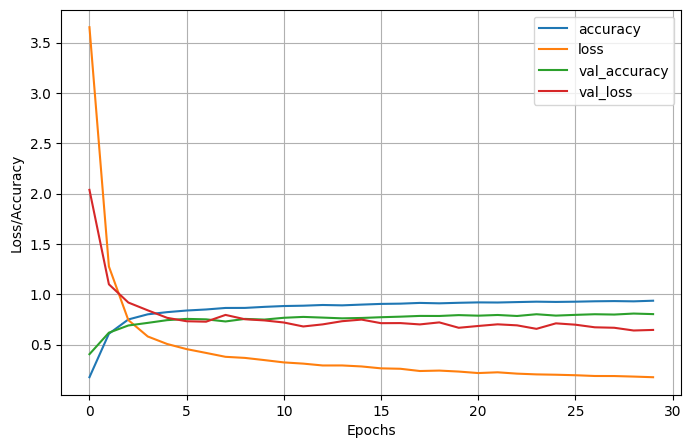

In [140]:
# Call once to ensure inputs are defined
_ = class_24_to_48_model_best(tf.zeros((1, 150, 150, 1)))

feature_extractor = keras.Sequential(class_24_to_48_model_best.layers[:-1])

# Build functional model
inputs = keras.Input(shape=(150, 150, 1))
features = feature_extractor(inputs)

x = keras.layers.Dense(256, activation='relu')(features)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs_72 = keras.layers.Dense(72, activation='softmax')(x)

class_48_to_72_model = keras.Model(inputs=inputs, outputs=outputs_72)

class_48_to_72_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_48_72 = class_48_to_72_model.fit(
    x_150_train_cat, y_150_train_categorical_72,
    batch_size=150,
    epochs=30,
    verbose=1,
    validation_data=(x_150_validation_cat, y_150_validation_categorical_72)
)


score = class_48_to_72_model.evaluate(
    x_150_validation_cat, y_150_validation_categorical_72, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print(evaluate_circular_mae_cat(class_48_to_72_model, x_150_validation_cat, y_150_validation, factor72))

pd.DataFrame(history_48_72.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epochs")
plt.ylabel("Loss/Accuracy")
#plt.gca().set_ylim(0, 1)
plt.show()

